## Libary Import and Data Load

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)

data_dir = Path("policeCalls")
adjusted_dir = Path("policacalls_adjusted")
adjusted_dir.mkdir(parents=True, exist_ok=True)

csv_files = [
    "policecalls2022.csv",
    "policecalls2023.csv",
    "policecalls2024.csv",
    "policecalls2025.csv",
    "policecalls2026.csv",
]

missing_files = [f for f in csv_files if not (data_dir / f).exists()]
if missing_files:
    raise FileNotFoundError(
        f"Missing files in {data_dir.resolve()}: {missing_files}"
    )

df_list = []
for file in csv_files:
    full_path = data_dir / file
    # Keep CDTS as string to avoid numeric/scientific coercion during load.
    temp = pd.read_csv(full_path, dtype={"CDTS": "string"}, low_memory=False)
    temp["source_file"] = file
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Combined shape:", df.shape)
display(df.head())
df.info()

print("\nColumns:")
print(df.columns.tolist())

print("\nRows by source file:")
display(df["source_file"].value_counts())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))
print(f"\nAdjusted output folder: {adjusted_dir.resolve()}")

Combined shape: (1170764, 16)


,CDTS,EID,START_DATE,CALL_NUMBER,PRIORITY,REPORT_DATE,OFFENSE_DATE,OFFENSE_TIME,CALLTYPE_CODE,CALL_TYPE,FINAL_DISPO_CODE,FINAL_DISPO,ADDRESS,CITY,STATE,source_file
0,20220101042916PS,8913184,1/1/2022 12:00:00 AM,P220010180,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,02:49:02,1066,SUSPICIOUS PERSON,N,No report required; dispatch record only,[800]-[900] JEANNE AV,San Jose,CA,policecalls2022.csv
1,20220101043036PS,8913196,1/1/2022 12:00:00 AM,P220010191,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,03:05:51,415,DISTURBANCE,N,No report required; dispatch record only,[1500]-[1600] SOUTHWEST EX,San Jose,CA,policecalls2022.csv
2,20220101043827PS,8913252,1/1/2022 12:00:00 AM,P220010236,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,04:35:25,911UNK,UNK TYPE 911 CALL,CAN,Canceled,[4800]-[4900] WESTMONT AV,San Jose,CA,policecalls2022.csv
3,20220101044026PS,8913216,1/1/2022 12:00:00 AM,P220010206,2,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,03:38:14,SUSCIR,SUSPICIOUS CIRCUMSTANCES,N,No report required; dispatch record only,[3600]-[3700] GREENLEE DR,San Jose,CA,policecalls2022.csv
4,20220102052501PS,8914182,1/1/2022 12:00:00 AM,P220010965,4,1/1/2022 12:00:00 AM,1/1/2022 12:00:00 AM,23:25:49,11300,NARCOTICS,A,Arrest Made,E CAPITOL EX & EVERGREEN PL,San Jose,CA,policecalls2022.csv


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170764 entries, 0 to 1170763
Data columns (total 16 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   CDTS              1170764 non-null  string
 1   EID               1170764 non-null  int64 
 2   START_DATE        1170764 non-null  object
 3   CALL_NUMBER       1170764 non-null  object
 4   PRIORITY          1170764 non-null  int64 
 5   REPORT_DATE       1170764 non-null  object
 6   OFFENSE_DATE      1170764 non-null  object
 7   OFFENSE_TIME      1170764 non-null  object
 8   CALLTYPE_CODE     1170764 non-null  object
 9   CALL_TYPE         1170764 non-null  object
 10  FINAL_DISPO_CODE  1170764 non-null  object
 11  FINAL_DISPO       1170764 non-null  object
 12  ADDRESS           1137620 non-null  object
 13  CITY              1170764 non-null  object
 14  STATE             1170764 non-null  object
 15  source_file       1170764 non-null  object
dtypes: int64(2), objec

source_file
policecalls2022.csv    294515
policecalls2023.csv    286481
policecalls2024.csv    276069
policecalls2025.csv    261724
policecalls2026.csv     51975
Name: count, dtype: int64


Missing values:


ADDRESS             33144
CDTS                    0
START_DATE              0
EID                     0
PRIORITY                0
REPORT_DATE             0
OFFENSE_DATE            0
CALL_NUMBER             0
OFFENSE_TIME            0
CALLTYPE_CODE           0
FINAL_DISPO_CODE        0
CALL_TYPE               0
FINAL_DISPO             0
CITY                    0
STATE                   0
source_file             0
dtype: int64


Adjusted output folder: D:\Coding Project\255_DataMining\Project\policacalls_adjusted


## Clean and Parse

In [19]:
def parse_cdts_series(raw_series: pd.Series) -> pd.Series:
    # Normalize raw values and remove known suffix noise.
    s = (
        raw_series.astype("string")
                  .str.upper()
                  .str.replace("PS", "", regex=False)
                  .str.strip()
    )

    # Primary parse: first 14 digits interpreted as YYYYMMDDHHMMSS.
    digits14 = s.str.extract(r"(\d{14})", expand=False)
    parsed = pd.to_datetime(digits14, format="%Y%m%d%H%M%S", errors="coerce")

    # Secondary parse: 12-digit timestamps (YYYYMMDDHHMM) -> append seconds.
    missing_mask = parsed.isna()
    if missing_mask.any():
        digits12 = s[missing_mask].str.extract(r"(\d{12})", expand=False)
        parsed12 = pd.to_datetime(digits12 + "00", format="%Y%m%d%H%M%S", errors="coerce")
        parsed.loc[missing_mask] = parsed12.values

    # Final fallback: let pandas infer any remaining odd formats.
    missing_mask = parsed.isna()
    if missing_mask.any():
        parsed_fallback = pd.to_datetime(s[missing_mask], errors="coerce")
        parsed.loc[missing_mask] = parsed_fallback.values

    return parsed

def parse_mixed_datetime_column(raw_series: pd.Series) -> pd.Series:
    s = raw_series.astype("string").str.strip()
    parsed = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")

    fmt_candidates = [
        "%Y%m%d%H%M%S",
        "%Y-%m-%d %H:%M:%S",
        "%Y-%m-%d %H:%M",
        "%m/%d/%Y %H:%M:%S",
        "%m/%d/%Y",
        "%Y/%m/%d %H:%M:%S",
        "%Y/%m/%d",
    ]

    for fmt in fmt_candidates:
        mask = parsed.isna()
        if not mask.any():
            break
        parsed_fmt = pd.to_datetime(s[mask], format=fmt, errors="coerce")
        parsed.loc[mask] = parsed_fmt.values

    # Generic fallback for any rows still unparsed.
    mask = parsed.isna()
    if mask.any():
        parsed.loc[mask] = pd.to_datetime(s[mask], errors="coerce").values

    return parsed

# Robust per-row parsing for CDTS.
df["CDTS"] = parse_cdts_series(df["CDTS"])

for col in ["START_DATE", "REPORT_DATE", "OFFENSE_DATE"]:
    if col in df.columns:
        df[col] = parse_mixed_datetime_column(df[col])

display(df[["CDTS"]].head())
print("Missing CDTS after parsing:", int(df["CDTS"].isna().sum()))

print("\nRows by parsed year:")
display(df["CDTS"].dt.year.value_counts().sort_index())

print("\nMonth coverage by source file (parsed CDTS):")
month_coverage = (
    df.dropna(subset=["CDTS"])
      .groupby(["source_file", df["CDTS"].dt.month])["CDTS"]
      .size()
      .unstack(fill_value=0)
      .reindex(columns=range(1, 13), fill_value=0)
)
display(month_coverage)

bad_cdts_sample = df.loc[df["CDTS"].isna(), ["source_file", "CDTS"]].head(10)
if not bad_cdts_sample.empty:
    print("\nSample unparsed CDTS rows (first 10):")
    display(bad_cdts_sample)

C:\Users\evusa\AppData\Local\Temp\ipykernel_34760\3643479539.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[mask] = pd.to_datetime(s[mask], errors="coerce").values
C:\Users\evusa\AppData\Local\Temp\ipykernel_34760\3643479539.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[mask] = pd.to_datetime(s[mask], errors="coerce").values
C:\Users\evusa\AppData\Local\Temp\ipykernel_34760\3643479539.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[mask] = pd.to_datetime(s[mask], errors="coerce").values


,CDTS
0,2022-01-01 04:29:16
1,2022-01-01 04:30:36
2,2022-01-01 04:38:27
3,2022-01-01 04:40:26
4,2022-01-02 05:25:01


Missing CDTS after parsing: 0

Rows by parsed year:


CDTS
2022    294473
2023    286471
2024    276071
2025    261738
2026     52011
Name: count, dtype: int64


Month coverage by source file (parsed CDTS):


CDTS,1,2,3,4,5,6,7,8,9,10,11,12
source_file,,,,,,,,,,,,
policecalls2022.csv,23390,21332,25315,23553,27064,26030,23623,26737,26074,26065,22617,22715
policecalls2023.csv,23559,21021,23440,23624,25346,24434,25499,24854,24046,24405,22524,23729
policecalls2024.csv,22055,22067,23666,21903,24527,23651,24243,23541,22932,23572,21669,22243
policecalls2025.csv,20952,19587,22619,21179,23693,22298,22818,23585,21901,21284,20508,21300
policecalls2026.csv,20595,18425,12955,0,0,0,0,0,0,0,0,0


## Clean the key analysis Columns

In [20]:
df["PRIORITY"] = pd.to_numeric(df["PRIORITY"], errors="coerce")
df["FINAL_DISPO"] = df["FINAL_DISPO"].astype(str).str.strip()
df["CALL_TYPE"] = df["CALL_TYPE"].astype(str).str.strip()

df = df.dropna(subset=["CDTS", "PRIORITY"]).copy()
df = df.sort_values("CDTS").reset_index(drop=True)

print("Cleaned shape:", df.shape)

print("\nPriority distribution:")
display(df["PRIORITY"].value_counts().sort_index())

print("\nTop FINAL_DISPO values:")
display(df["FINAL_DISPO"].value_counts().head(20))

print("\nTop CALL_TYPE values:")
display(df["CALL_TYPE"].value_counts().head(20))

print("\nRows by source file after cleaning:")
display(df["source_file"].value_counts())

print("\nRows by year after cleaning:")
display(df["CDTS"].dt.year.value_counts().sort_index())

# Write cleaned per-file outputs without changing raw source files.
for file_name, chunk in df.groupby("source_file", sort=False):
    out_path = adjusted_dir / file_name
    chunk.drop(columns=["source_file"], errors="ignore").to_csv(out_path, index=False)

combined_out_path = adjusted_dir / "policecalls_adjusted_all.csv"
df.drop(columns=["source_file"], errors="ignore").to_csv(combined_out_path, index=False)

print(f"\nSaved cleaned files to: {adjusted_dir.resolve()}")
print(f"Combined cleaned file: {combined_out_path.resolve()}")

Cleaned shape: (1170764, 16)

Priority distribution:


PRIORITY
1     37179
2    367747
3    406181
4    135423
5     77728
6    146503
8         3
Name: count, dtype: int64


Top FINAL_DISPO values:


FINAL_DISPO
No report required; dispatch record only            531351
Canceled                                            235071
Report taken                                        153745
Gone on Arrival/unable to locate                     51846
No Disposition                                       43262
Arrest Made                                          22850
Traffic Citation Issued, Hazardous Violation         22750
Traffic Citation Issued, Non-Hazardous Violation     21926
Supplemental report taken                            21323
Unfounded event                                      16882
Courtesy Service/Citizen or agency assist            13594
Turned over To (TOT)                                 11155
Criminal Citation                                     9697
Arrest by Warrant                                     8013
No Response                                           3777
Field Interview (F.I.) Completed                      3269
Stranded motorist assist                    


Top CALL_TYPE values:


...


Rows by source file after cleaning:


source_file
policecalls2022.csv    294515
policecalls2023.csv    286481
policecalls2024.csv    276069
policecalls2025.csv    261724
policecalls2026.csv     51975
Name: count, dtype: int64


Rows by year after cleaning:


CDTS
2022    294473
2023    286471
2024    276071
2025    261738
2026     52011
Name: count, dtype: int64


Saved cleaned files to: D:\Coding Project\255_DataMining\Project\policacalls_adjusted
Combined cleaned file: D:\Coding Project\255_DataMining\Project\policacalls_adjusted\policecalls_adjusted_all.csv


## Create time-based features

In [21]:
df["year"] = df["CDTS"].dt.year
df["month"] = df["CDTS"].dt.month
# Keep as datetime (not Python date objects) for faster grouping/resampling.
df["day"] = df["CDTS"].dt.floor("D")
df["hour"] = df["CDTS"].dt.hour
df["day_of_week"] = df["CDTS"].dt.day_name()
df["is_weekend"] = df["CDTS"].dt.dayofweek >= 5

display(df[["CDTS", "year", "month", "day", "hour", "day_of_week", "is_weekend"]].head())

,CDTS,year,month,day,hour,day_of_week,is_weekend
0,2022-01-01 00:03:07,2022,1,2022-01-01,0,Saturday,True
1,2022-01-01 00:03:54,2022,1,2022-01-01,0,Saturday,True
2,2022-01-01 00:06:18,2022,1,2022-01-01,0,Saturday,True
3,2022-01-01 00:08:03,2022,1,2022-01-01,0,Saturday,True
4,2022-01-01 00:11:15,2022,1,2022-01-01,0,Saturday,True


## Creating flags for canceled calls and priority groups

In [22]:
df["FINAL_DISPO_upper"] = df["FINAL_DISPO"].str.upper()
df["is_canceled"] = df["FINAL_DISPO_upper"].str.contains("CANCEL", na=False)

df["is_p1"] = df["PRIORITY"] == 1
df["is_p3_p4"] = df["PRIORITY"].isin([3, 4])
df["is_canceled_p3_p4"] = df["is_canceled"] & df["is_p3_p4"]

display(df[["PRIORITY", "FINAL_DISPO", "is_canceled", "is_p1", "is_p3_p4", "is_canceled_p3_p4"]].head())

,PRIORITY,FINAL_DISPO,is_canceled,is_p1,is_p3_p4,is_canceled_p3_p4
0,4,Canceled,True,False,True,True
1,2,Canceled,True,False,False,False
2,4,Canceled,True,False,True,True
3,4,Canceled,True,False,True,True
4,6,No report required; dispatch record only,False,False,False,False


## basic descriptive EDA

In [23]:
# Faster than groupby-size for single-key counts on large data.
daily_calls = (
    df["day"].value_counts(sort=False)
      .sort_index()
      .rename_axis("day")
      .reset_index(name="total_calls")
)
hourly_calls = (
    df["hour"].value_counts(sort=False)
      .sort_index()
      .rename_axis("hour")
      .reset_index(name="total_calls")
)

priority_counts = df["PRIORITY"].value_counts().sort_index().reset_index()
priority_counts.columns = ["PRIORITY", "count"]

cancel_by_priority = (
    df.groupby("PRIORITY", sort=True, observed=False)
      .agg(
          total_calls=("PRIORITY", "size"),
          canceled_calls=("is_canceled", "sum"),
          canceled_p3_p4=("is_canceled_p3_p4", "sum")
      )
      .reset_index()
)

cancel_by_priority["cancel_rate"] = cancel_by_priority["canceled_calls"] / cancel_by_priority["total_calls"]

display(daily_calls.head())
display(hourly_calls.head())
display(priority_counts)
display(cancel_by_priority)

,day,total_calls
0,2022-01-01,794
1,2022-01-02,726
2,2022-01-03,804
3,2022-01-04,796
4,2022-01-05,848


,hour,total_calls
0,0,64295
1,1,50858
2,2,38678
3,3,30849
4,4,24576


,PRIORITY,count
0,1,37179
1,2,367747
2,3,406181
3,4,135423
4,5,77728
5,6,146503
6,8,3


,PRIORITY,total_calls,canceled_calls,canceled_p3_p4,cancel_rate
0,1,37179,1901,0,0.051131
1,2,367747,59675,0,0.162272
2,3,406181,113738,113738,0.280018
3,4,135423,57524,57524,0.424773
4,5,77728,698,0,0.008980
5,6,146503,1533,0,0.010464
6,8,3,2,0,0.666667


## Plot the basic desc patterns

Filled 3 missing calendar days with 0 calls.
Daily chart downsampled to 770 points using 2-day bins.


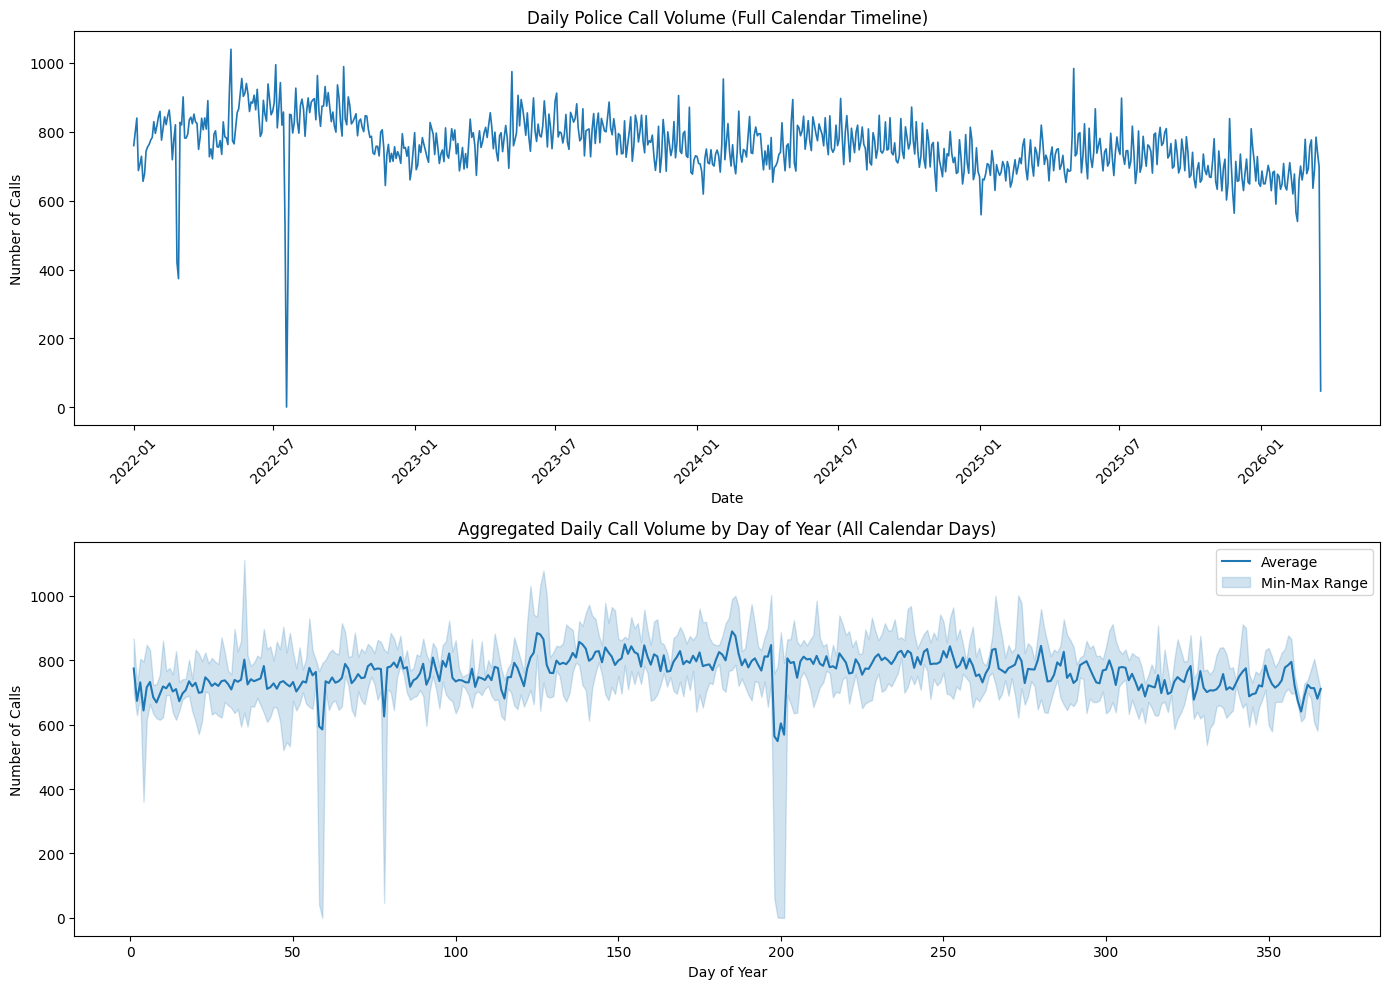

,day_of_year,avg_calls,min_calls,max_calls,sample_days
0,1,774.2,702,867,5
1,2,673.8,629,726,5
2,3,731.2,693,804,5
3,4,644.0,361,796,5
4,5,716.0,616,848,5
5,6,732.4,664,832,5
6,7,684.8,634,723,5
7,8,668.8,620,726,5
8,9,694.0,615,754,5
9,10,718.4,623,861,5


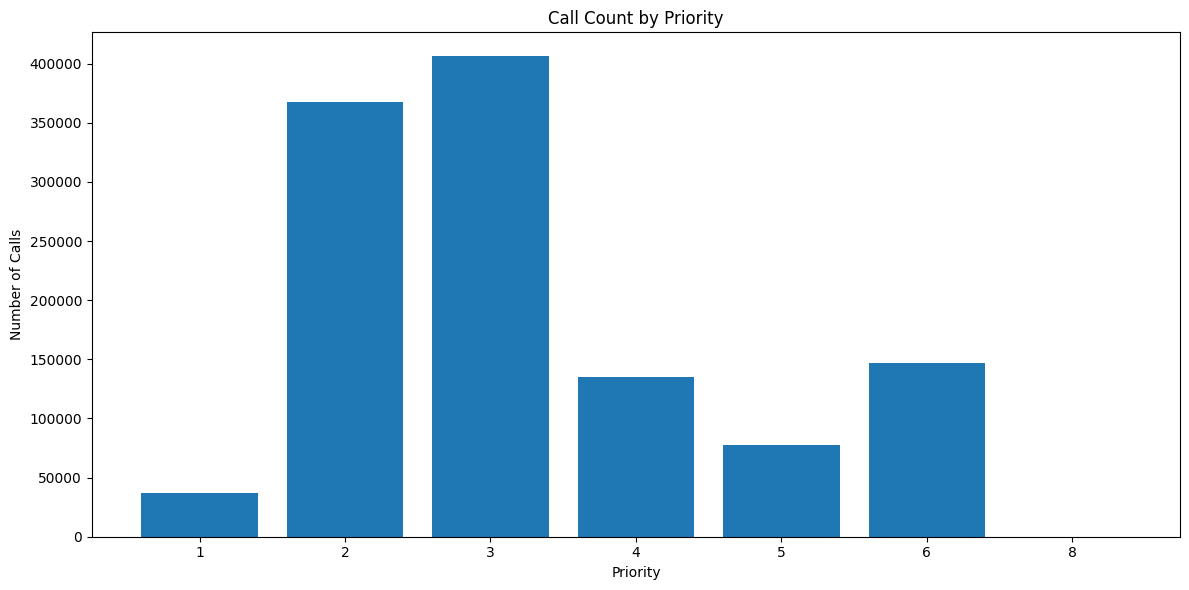

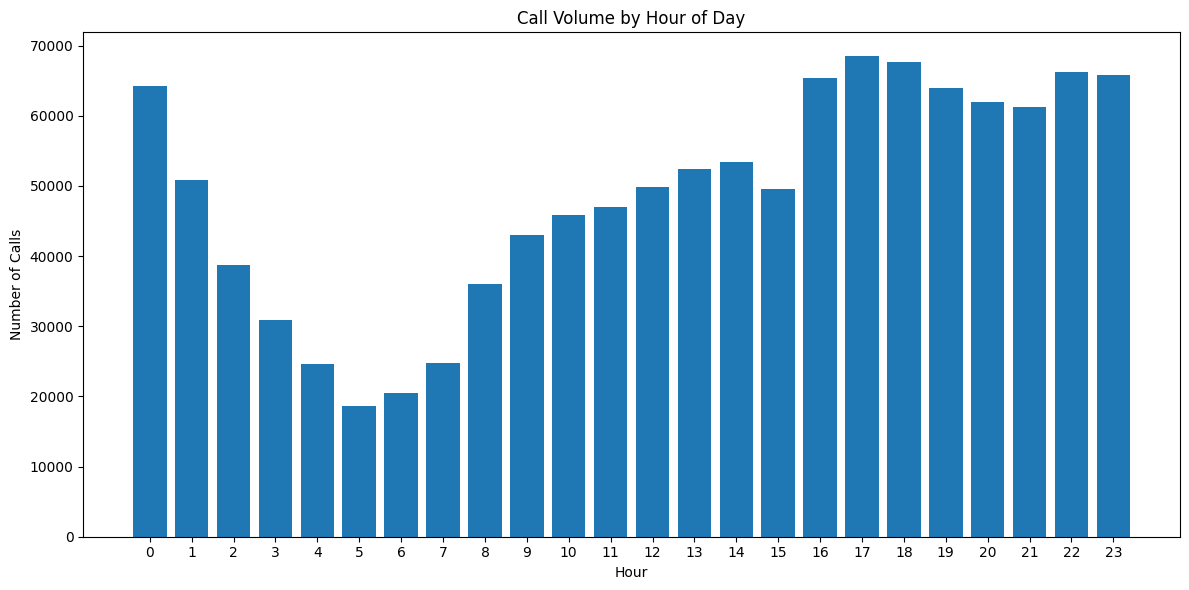

In [24]:
# Reuse pre-aggregated daily counts to avoid re-scanning the full dataframe.
daily_observed = daily_calls.copy()
daily_observed["day"] = pd.to_datetime(daily_observed["day"])

# Build a full calendar timeline and fill missing days with 0 so every day is represented.
full_day_index = pd.date_range(
    daily_observed["day"].min(),
    daily_observed["day"].max(),
    freq="D"
)
daily_timeline = (
    daily_observed.set_index("day")
                  .reindex(full_day_index, fill_value=0)
                  .rename_axis("day")
                  .reset_index()
                  .rename(columns={"index": "day"})
)
daily_timeline["total_calls"] = daily_timeline["total_calls"].astype("int32")

missing_day_count = int(len(full_day_index) - len(daily_observed))
print(f"Filled {missing_day_count:,} missing calendar days with 0 calls.")

# Keep plotting responsive by downsampling only for visualization when needed.
daily_plot = daily_timeline
max_daily_points = 900
if len(daily_plot) > max_daily_points:
    plot_bin_days = max(int(np.ceil(len(daily_plot) / max_daily_points)), 1)
    daily_plot = (
        daily_plot.set_index("day")["total_calls"]
                 .resample(f"{plot_bin_days}D")
                 .mean()
                 .reset_index()
    )
    print(f"Daily chart downsampled to {len(daily_plot):,} points using {plot_bin_days}-day bins.")
else:
    print(f"Daily chart uses full daily resolution ({len(daily_plot):,} points).")

# Aggregate all calendar days-of-year (1..366) from the full timeline.
doy_stats = (
    daily_timeline.assign(day_of_year=daily_timeline["day"].dt.dayofyear)
                  .groupby("day_of_year", sort=True, as_index=True)["total_calls"]
                  .agg(avg_calls="mean", min_calls="min", max_calls="max", sample_days="size")
)

# Fast fixed-size index to guarantee full 1..366 coverage.
doy_profile = (
    doy_stats.reindex(np.arange(1, 367))
             .rename_axis("day_of_year")
             .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(daily_plot["day"], daily_plot["total_calls"], linewidth=1.2)
axes[0].set_title("Daily Police Call Volume (Full Calendar Timeline)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Number of Calls")
axes[0].tick_params(axis="x", rotation=45)

valid_doy = doy_profile.dropna(subset=["avg_calls", "min_calls", "max_calls"])
axes[1].plot(valid_doy["day_of_year"], valid_doy["avg_calls"], color="tab:blue", label="Average")
axes[1].fill_between(
    valid_doy["day_of_year"],
    valid_doy["min_calls"],
    valid_doy["max_calls"],
    color="tab:blue",
    alpha=0.2,
    label="Min-Max Range"
)
axes[1].set_title("Aggregated Daily Call Volume by Day of Year (All Calendar Days)")
axes[1].set_xlabel("Day of Year")
axes[1].set_ylabel("Number of Calls")
axes[1].legend()

plt.tight_layout()
plt.show()

display(doy_profile.head(10))

plt.figure()
plt.bar(priority_counts["PRIORITY"].astype(str), priority_counts["count"])
plt.title("Call Count by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(hourly_calls["hour"].astype(str), hourly_calls["total_calls"])
plt.title("Call Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

## Examine when canceled lower-prio calls happen

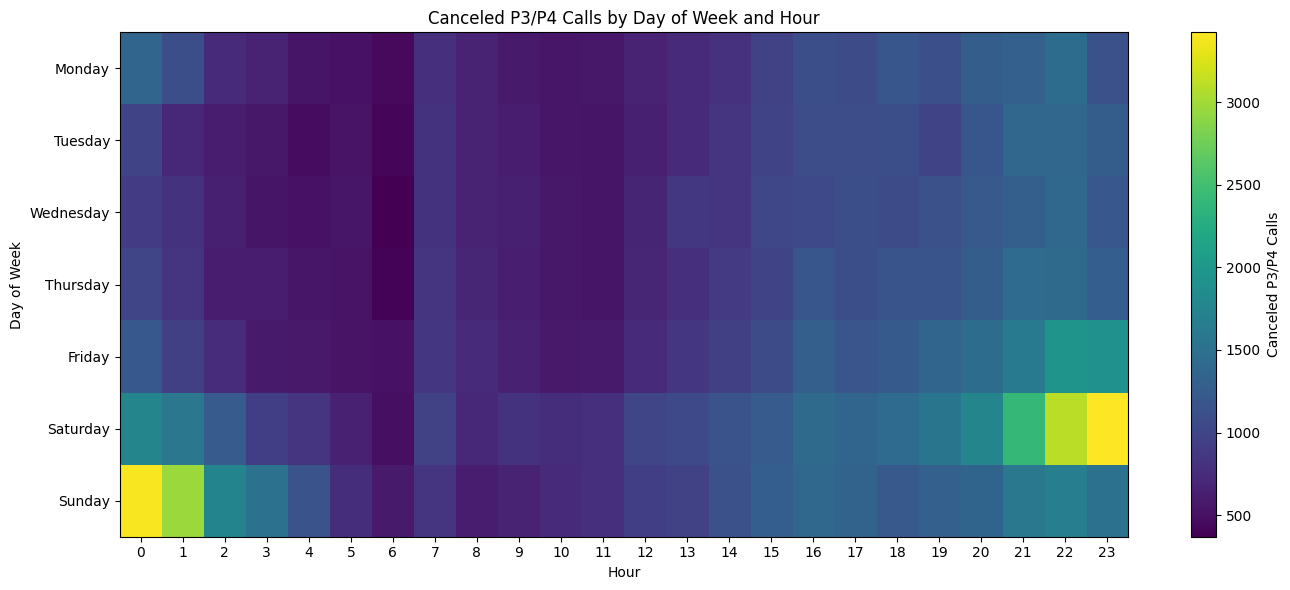

In [25]:
cancel_heat = (
    df.groupby(["day_of_week", "hour"])["is_canceled_p3_p4"]
      .sum()
      .unstack(fill_value=0)
)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
cancel_heat = cancel_heat.reindex(day_order)

plt.figure(figsize=(14, 6))
plt.imshow(cancel_heat, aspect="auto")
plt.colorbar(label="Canceled P3/P4 Calls")
plt.title("Canceled P3/P4 Calls by Day of Week and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.xticks(range(24), range(24))
plt.yticks(range(len(cancel_heat.index)), cancel_heat.index)
plt.tight_layout()
plt.show()

## Aggregate the data into a stress table

In [26]:
# Create short time windows for stress analysis
time_bin_size = "5min"
df["time_bin"] = df["CDTS"].dt.floor(time_bin_size)

display(df[["CDTS", "time_bin"]].head())

# Vectorized flags make aggregation much faster than groupby-apply on large datasets.
df["is_p1_row"] = (df["PRIORITY"] == 1).astype("int8")
df["is_p3_p4_row"] = df["PRIORITY"].isin([3, 4]).astype("int8")
df["is_canceled_p3_p4_row"] = (df["is_canceled"] & df["PRIORITY"].isin([3, 4])).astype("int8")

agg = (
    df.groupby("time_bin", as_index=False)
      .agg(
          total_calls=("PRIORITY", "size"),
          p1_calls=("is_p1_row", "sum"),
          p3_p4_calls=("is_p3_p4_row", "sum"),
          canceled_p3_p4=("is_canceled_p3_p4_row", "sum"),
          all_canceled=("is_canceled", "sum")
      )
)

agg["cancel_rate_p3_p4"] = np.where(
    agg["p3_p4_calls"] > 0,
    agg["canceled_p3_p4"] / agg["p3_p4_calls"],
    np.nan
)

agg["has_p1"] = agg["p1_calls"] > 0

display(agg.head())
display(agg.describe(include="all"))

,CDTS,time_bin
0,2022-01-01 00:03:07,2022-01-01 00:00:00
1,2022-01-01 00:03:54,2022-01-01 00:00:00
2,2022-01-01 00:06:18,2022-01-01 00:05:00
3,2022-01-01 00:08:03,2022-01-01 00:05:00
4,2022-01-01 00:11:15,2022-01-01 00:10:00


,time_bin,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,all_canceled,cancel_rate_p3_p4,has_p1
0,2022-01-01 00:00:00,2,0,1,1,2,1.0,False
1,2022-01-01 00:05:00,2,0,2,2,2,1.0,False
2,2022-01-01 00:10:00,2,0,1,1,1,1.0,False
3,2022-01-01 00:15:00,1,0,1,1,1,1.0,False
4,2022-01-01 00:20:00,2,0,2,2,2,1.0,False


,time_bin,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,all_canceled,cancel_rate_p3_p4,has_p1
count,388090,388090.000000,388090.000000,388090.000000,388090.000000,388090.000000,291486.000000,388090
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,352761
mean,2024-02-06 07:17:58.681233408,3.016733,0.095800,1.395563,0.441295,0.605713,0.302393,NaN
min,2022-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2023-01-19 21:51:15,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
50%,2024-02-04 15:17:30,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
75%,2025-02-22 19:38:45,4.000000,0.000000,2.000000,1.000000,1.000000,0.500000,NaN
max,2026-03-19 05:30:00,20.000000,4.000000,17.000000,17.000000,17.000000,1.000000,NaN


## Compare Prio 1 activity against canceled lower-prio calls

Plot downsampled to 1,997 points using 66451s bins.


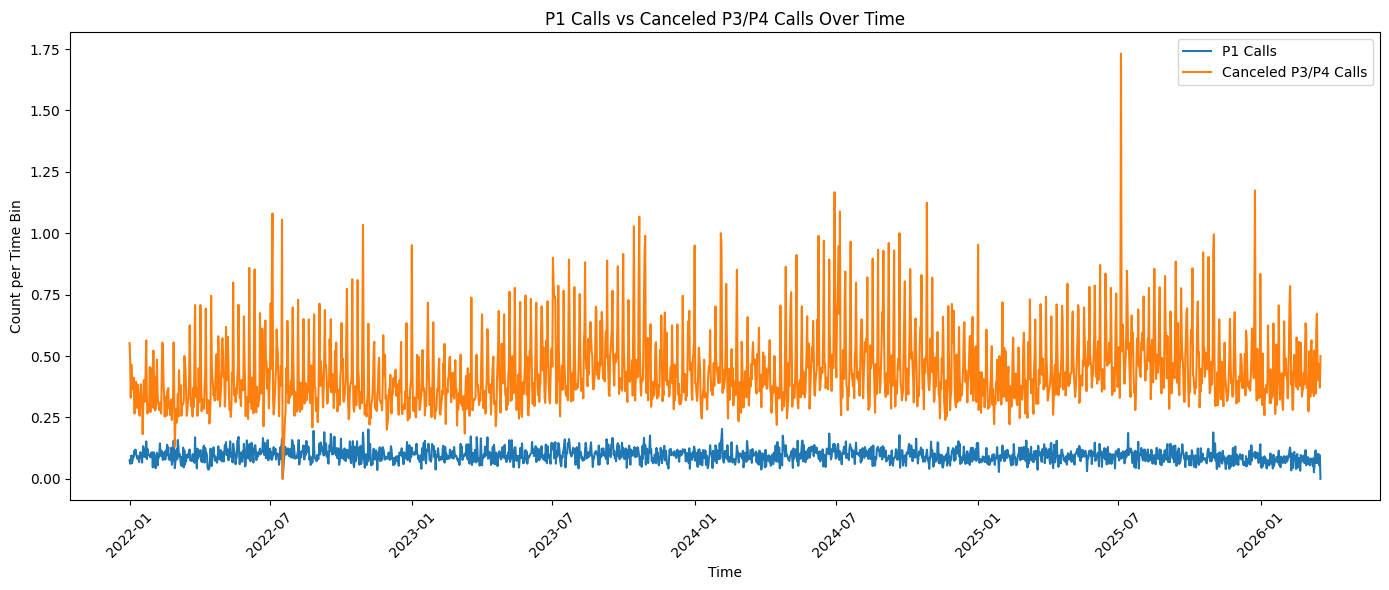

In [27]:
plot_agg = agg.sort_values("time_bin").copy()
max_plot_points = 2000

if len(plot_agg) > max_plot_points:
    total_span_seconds = max(
        (plot_agg["time_bin"].max() - plot_agg["time_bin"].min()).total_seconds(),
        1
    )
    resample_seconds = max(int(total_span_seconds / max_plot_points), 1)
    resample_rule = f"{resample_seconds}s"

    plot_agg = (
        plot_agg.set_index("time_bin")[["p1_calls", "canceled_p3_p4"]]
               .resample(resample_rule)
               .mean()
               .dropna(how="all")
               .reset_index()
    )
    print(f"Plot downsampled to {len(plot_agg):,} points using {resample_rule} bins.")
else:
    print(f"Plot uses full resolution ({len(plot_agg):,} points).")

plt.figure(figsize=(14, 6))
plt.plot(plot_agg["time_bin"], plot_agg["p1_calls"], label="P1 Calls")
plt.plot(plot_agg["time_bin"], plot_agg["canceled_p3_p4"], label="Canceled P3/P4 Calls")
plt.title("P1 Calls vs Canceled P3/P4 Calls Over Time")
plt.xlabel("Time")
plt.ylabel("Count per Time Bin")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Compare window with and without P1 calls

In [28]:
p1_compare = (
    agg.groupby("has_p1")
       .agg(
           bins=("time_bin", "count"),
           avg_p1_calls=("p1_calls", "mean"),
           avg_canceled_p3_p4=("canceled_p3_p4", "mean"),
           avg_cancel_rate_p3_p4=("cancel_rate_p3_p4", "mean")
       )
       .reset_index()
)

display(p1_compare)

,has_p1,bins,avg_p1_calls,avg_canceled_p3_p4,avg_cancel_rate_p3_p4
0,False,352761,0.000000,0.44061,0.301757
1,True,35329,1.052365,0.44813,0.309304


## Search for the breaking point

,p1_bin,num_bins,avg_canceled_p3_p4,avg_cancel_rate_p3_p4,median_cancel_rate_p3_p4
0,0,352761,0.440610,0.301757,0.0
1,1,33570,0.447364,0.309582,0.0
2,2,1674,0.458184,0.307087,0.0
3,3,79,0.569620,0.248830,0.0
4,4+,6,0.333333,0.222222,0.0


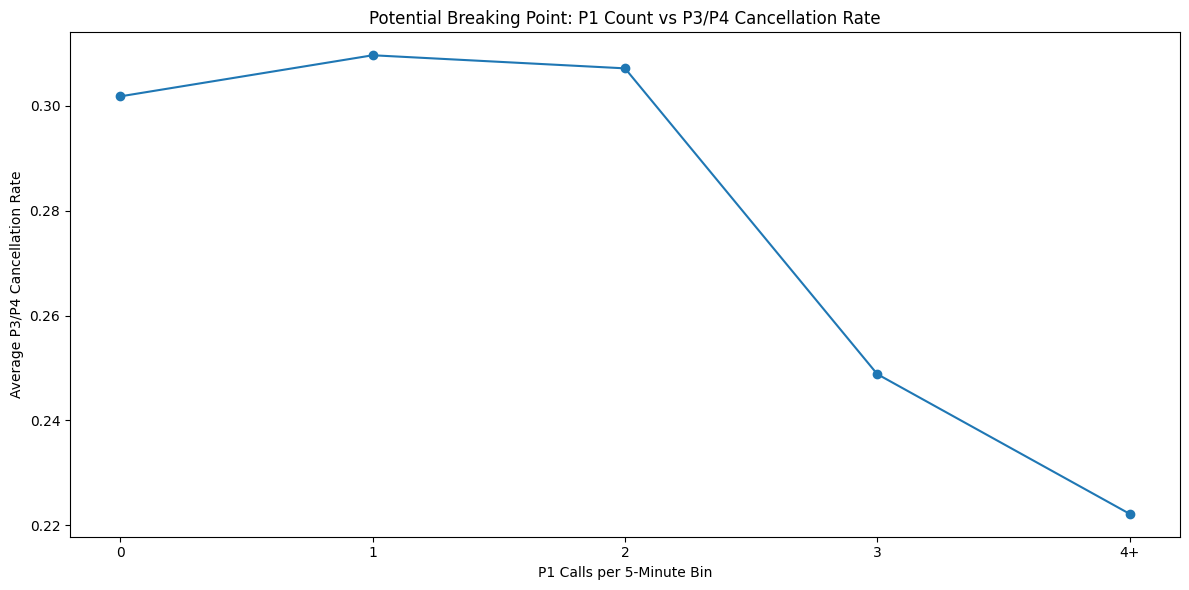

In [29]:
agg["p1_bin"] = pd.cut(
    agg["p1_calls"],
    bins=[-1, 0, 1, 2, 3, 100],
    labels=["0", "1", "2", "3", "4+"]
)

breaking_point = (
    agg.groupby("p1_bin", observed=False)
       .agg(
           num_bins=("time_bin", "count"),
           avg_canceled_p3_p4=("canceled_p3_p4", "mean"),
           avg_cancel_rate_p3_p4=("cancel_rate_p3_p4", "mean"),
           median_cancel_rate_p3_p4=("cancel_rate_p3_p4", "median")
       )
       .reset_index()
)

display(breaking_point)

plt.figure()
plt.plot(breaking_point["p1_bin"].astype(str), breaking_point["avg_cancel_rate_p3_p4"], marker="o")
plt.title("Potential Breaking Point: P1 Count vs P3/P4 Cancellation Rate")
plt.xlabel("P1 Calls per 5-Minute Bin")
plt.ylabel("Average P3/P4 Cancellation Rate")
plt.tight_layout()
plt.show()

## Compute simple relationship measures

In [30]:
prob_with_p1 = agg.loc[agg["has_p1"], "cancel_rate_p3_p4"].mean()
prob_without_p1 = agg.loc[~agg["has_p1"], "cancel_rate_p3_p4"].mean()

print("Average P3/P4 cancellation rate when there is at least one P1 call:", prob_with_p1)
print("Average P3/P4 cancellation rate when there are no P1 calls:", prob_without_p1)

corr_value = agg[["p1_calls", "canceled_p3_p4"]].corr().iloc[0, 1]
print("Correlation between P1 calls and canceled P3/P4 calls:", corr_value)

Average P3/P4 cancellation rate when there is at least one P1 call: 0.3093042360257579
Average P3/P4 cancellation rate when there are no P1 calls: 0.3017570359093535
Correlation between P1 calls and canceled P3/P4 calls: 0.00310651048552194


## Find top stress windows for case studies

In [31]:
top_stress_windows = agg.sort_values(
    ["canceled_p3_p4", "p1_calls", "total_calls"],
    ascending=[False, False, False]
).head(20)

display(top_stress_windows)

,time_bin,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,all_canceled,cancel_rate_p3_p4,has_p1,p1_bin
367241,2025-12-24 04:30:00,17,0,17,17,17,1.000000,False,0
367503,2025-12-25 04:10:00,17,1,16,15,15,0.937500,True,1
194058,2024-02-04 16:25:00,19,1,17,13,13,0.764706,True,1
58154,2022-08-21 01:00:00,18,1,17,13,13,0.764706,True,1
169143,2023-10-29 01:45:00,18,1,13,13,14,1.000000,True,1
167319,2023-10-21 22:35:00,16,0,14,13,14,0.928571,False,0
44590,2022-06-25 22:50:00,15,0,14,13,13,0.928571,False,0
142277,2023-07-16 00:55:00,19,1,14,12,12,0.857143,True,1
261470,2024-10-27 03:40:00,14,0,14,12,12,0.857143,False,0
340342,2025-09-06 23:45:00,14,0,12,12,12,1.000000,False,0


## Inspect one specific event window

In [32]:
if not top_stress_windows.empty:
    selected_window = top_stress_windows.iloc[0]["time_bin"]
    start_window = selected_window - pd.Timedelta(minutes=15)
    end_window = selected_window + pd.Timedelta(minutes=15)

    event_slice = df[(df["CDTS"] >= start_window) & (df["CDTS"] <= end_window)].copy()
    event_slice = event_slice.sort_values("CDTS")

    print("Case study window:", start_window, "to", end_window)
    
    cols_to_show = ["CDTS", "PRIORITY", "CALL_TYPE", "FINAL_DISPO"]
    if "ADDRESS" in event_slice.columns:
        cols_to_show.append("ADDRESS")

    display(event_slice[cols_to_show])

Case study window: 2025-12-24 04:15:00 to 2025-12-24 04:45:00


,CDTS,PRIORITY,CALL_TYPE,FINAL_DISPO,ADDRESS
1113493,2025-12-24 04:19:09,3,ALARM,No report required; dispatch record only,[3600]-[3700] PEARL AV
1113494,2025-12-24 04:21:02,3,DISTURBANCE,No report required; dispatch record only,[1800]-[1800] STOKES ST
1113495,2025-12-24 04:21:07,2,WELFARE CHECK,Report taken,BURTON AV & N 1ST ST
1113496,2025-12-24 04:21:38,3,"ALARM, AUDIBLE",No report required; dispatch record only,[1000]-[1100] FOXWORTHY AV
1113497,2025-12-24 04:23:40,3,TRAFFIC HAZARD,No Disposition,[1200]-[1300] THORNBURY LN
1113498,2025-12-24 04:27:06,3,"ALARM, AUDIBLE",Canceled,[2100]-[2200] MONTEREY RD
1113499,2025-12-24 04:27:20,3,"ALARM, AUDIBLE",Canceled,[900]-[1000] OAKLAND RD
1113500,2025-12-24 04:28:00,1,EXPLOSION,No report required; dispatch record only,ALMADEN EX & IRONWOOD DR
1113501,2025-12-24 04:29:10,3,"ALARM, AUDIBLE",Canceled,[0]-[100] KEYES ST
1113502,2025-12-24 04:31:03,3,"ALARM, AUDIBLE",Canceled,[1600]-[1600] SARATOGA AV


## build a yearly and monthly summary

,year,month,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,cancel_rate_p3_p4
0,2022,1,23348,738,9966,2782,0.279149
1,2022,2,21332,635,8507,2282,0.268250
2,2022,3,25315,710,10357,2795,0.269866
3,2022,4,23553,676,10420,3046,0.292322
4,2022,5,27064,845,11183,3354,0.299920
5,2022,6,26030,875,11159,3240,0.290349
6,2022,7,23623,746,10277,3227,0.314002
7,2022,8,26737,824,11300,3084,0.272920
8,2022,9,26074,891,11257,3246,0.288354
9,2022,10,26065,821,11132,3476,0.312253


,year,total_calls,p1_calls,p3_p4_calls,canceled_p3_p4,cancel_rate_p3_p4
0,2022,294473,9183,125478,35981,0.286751
1,2023,286471,9296,132652,41202,0.310602
2,2024,276071,8997,129875,43067,0.331603
3,2025,261738,8248,127789,42733,0.334403
4,2026,52011,1455,25810,8279,0.320767


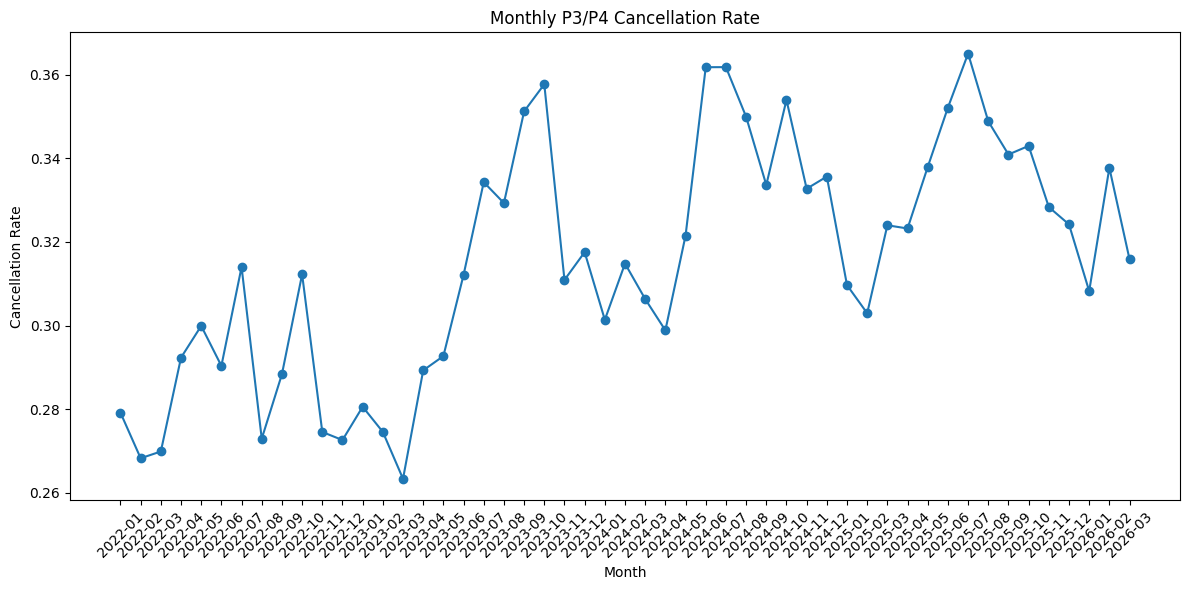

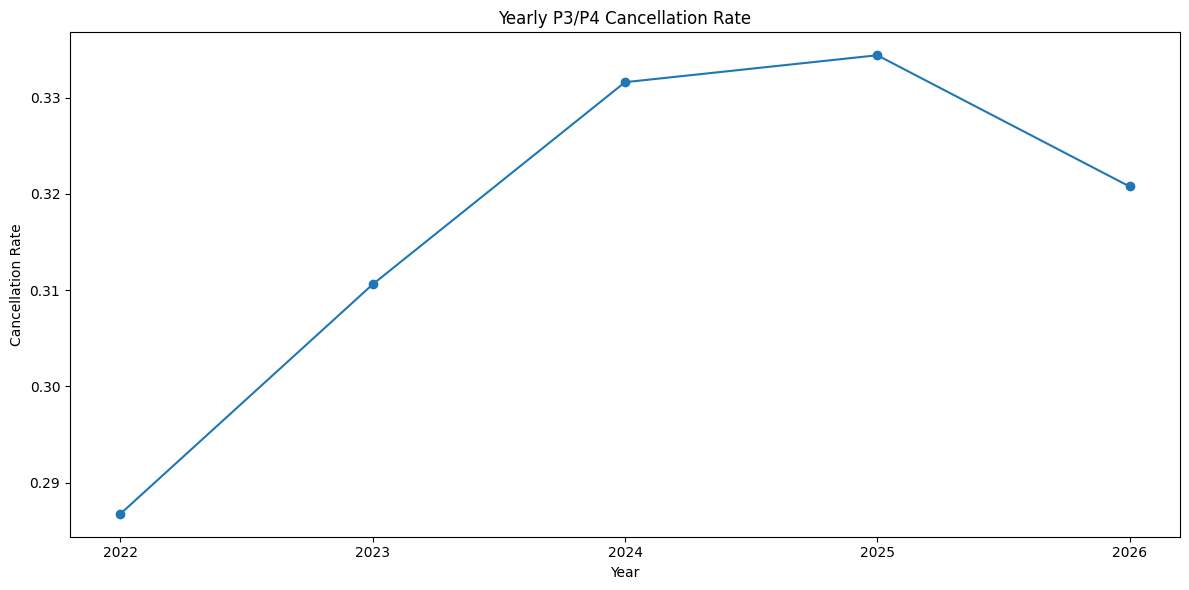

In [33]:
monthly_summary = (
    df.groupby(["year", "month"])
      .agg(
          total_calls=("PRIORITY", "size"),
          p1_calls=("is_p1", "sum"),
          p3_p4_calls=("is_p3_p4", "sum"),
          canceled_p3_p4=("is_canceled_p3_p4", "sum")
      )
      .reset_index()
)

monthly_summary["cancel_rate_p3_p4"] = np.where(
    monthly_summary["p3_p4_calls"] > 0,
    monthly_summary["canceled_p3_p4"] / monthly_summary["p3_p4_calls"],
    np.nan
)

yearly_summary = (
    df.groupby("year")
      .agg(
          total_calls=("PRIORITY", "size"),
          p1_calls=("is_p1", "sum"),
          p3_p4_calls=("is_p3_p4", "sum"),
          canceled_p3_p4=("is_canceled_p3_p4", "sum")
      )
      .reset_index()
)

yearly_summary["cancel_rate_p3_p4"] = np.where(
    yearly_summary["p3_p4_calls"] > 0,
    yearly_summary["canceled_p3_p4"] / yearly_summary["p3_p4_calls"],
    np.nan
)

# Sort before summary display and plotting for correct chronological order
monthly_summary = monthly_summary.sort_values(["year", "month"]).reset_index(drop=True)
yearly_summary = yearly_summary.sort_values("year").reset_index(drop=True)


display(monthly_summary)
display(yearly_summary)

plt.figure()
month_labels = monthly_summary["year"].astype(str) + "-" + monthly_summary["month"].astype(str).str.zfill(2)
plt.plot(month_labels, monthly_summary["cancel_rate_p3_p4"], marker="o")
plt.title("Monthly P3/P4 Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(yearly_summary["year"].astype(str), yearly_summary["cancel_rate_p3_p4"], marker="o")
plt.title("Yearly P3/P4 Cancellation Rate")
plt.xlabel("Year")
plt.ylabel("Cancellation Rate")
plt.tight_layout()
plt.show()

## Print a compact EDA summary

In [34]:
summary_stats = {
    "total_rows_after_cleaning": int(len(df)),
    "date_min": df["CDTS"].min(),
    "date_max": df["CDTS"].max(),
    "total_p1_calls": int(df["is_p1"].sum()),
    "total_p3_p4_calls": int(df["is_p3_p4"].sum()),
    "total_canceled_calls": int(df["is_canceled"].sum()),
    "total_canceled_p3_p4": int(df["is_canceled_p3_p4"].sum()),
    "avg_cancel_rate_with_p1": float(prob_with_p1) if pd.notna(prob_with_p1) else np.nan,
    "avg_cancel_rate_without_p1": float(prob_without_p1) if pd.notna(prob_without_p1) else np.nan,
    "p1_cancel_corr": float(corr_value) if pd.notna(corr_value) else np.nan
}

print("\nEDA Summary Stats")
for k, v in summary_stats.items():
    print(f"{k}: {v}")


EDA Summary Stats
total_rows_after_cleaning: 1170764
date_min: 2022-01-01 00:03:07
date_max: 2026-03-19 05:31:36
total_p1_calls: 37179
total_p3_p4_calls: 541604
total_canceled_calls: 235071
total_canceled_p3_p4: 171262
avg_cancel_rate_with_p1: 0.3093042360257579
avg_cancel_rate_without_p1: 0.3017570359093535
p1_cancel_corr: 0.00310651048552194
